#  MuJoCo Bootcamp : Linear Quadratic Regulator

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/HMyD0IfPHfA

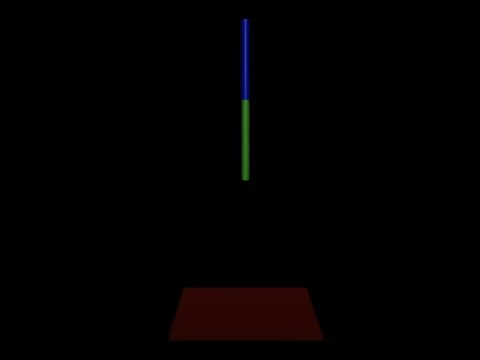

In [9]:
from IPython.display import YouTubeVideo

YouTubeVideo('HMyD0IfPHfA')

## Run python code

In [ ]:
!python doublependulum_lqr.py 

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media
from numpy.linalg import inv
from scipy.linalg import solve_continuous_are
import os

# Create an XML file string for a simple ball on a plane
xml_path = "./doublependulum.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [2]:
def get_dx(inputs):
    """
    The state is [q1, dq1, q2, dq2]
    The inputs are [q1, dq1, q2, dq2, u]

    The function outputs [dq1, ddq1, dq2, ddq2]
    """
    # Apply inputs
    data.qpos[0] = inputs[0]
    data.qvel[0] = inputs[1]
    data.qpos[1] = inputs[2]
    data.qvel[1] = inputs[3]
    data.ctrl[0] = inputs[4]

    mj.mj_forward(model, data)

    # Record outputs
    dq1 = data.qvel[0]
    dq2 = data.qvel[1]

    # Convert sparse inertia matrix M into full (i.e. dense) matrix.
    # M is filled with the data from data.qM
    M = np.zeros((2, 2))
    mj.mj_fullM(model, M, data.qM)

    # Calculate f = ctrl - qfrc_bias
    f = np.array([
        [0 - data.qfrc_bias[0]],
        [data.ctrl[0] - data.qfrc_bias[1]]
    ])

    # Calculate qacc
    ddq = inv(M) @ f

    outputs = np.array([dq1, ddq[0, 0], dq2, ddq[1, 0]])

    return outputs

def linearization(pert=0.001):
    f0 = get_dx(np.zeros(5))

    Jacobians = []
    for i in range(5):
        inputs_i = np.zeros(5)
        inputs_i[i] = pert
        jac = (get_dx(inputs_i) - f0) / pert
        Jacobians.append(jac[:, np.newaxis])

    A = np.concatenate(Jacobians[:4], axis=1)
    B = Jacobians[-1]

    return A, B

def controller(model, data):
    """
    This function implements a LQR controller for balancing.
    """
    state = np.array([
        [data.qpos[0]],
        [data.qvel[0]],
        [data.qpos[1]],
        [data.qvel[1]],
    ])
    data.ctrl[0] = (K @ state)[0, 0]

    # Apply noise to shoulder
    noise = mj.mju_standardNormal(0.0)
    data.qfrc_applied[0] = noise

# Compute LQR gain
A, B = linearization()
Q = np.diag([10, 10, 10, 10])
R = np.diag([0.1])
P = solve_continuous_are(A, B, Q, R)
K = -inv(B.T @ P @ B + R) @ B.T @ P @ A

#set the controller
mj.set_mjcb_control(controller)

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 1.5])

### Initialization 

In [4]:
# Reset the data to initial state
mj.mj_resetData(model, data)
mj.mj_forward(model, data)



### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 60
simend = 10


while data.time < simend:
    simstart = data.time
    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
